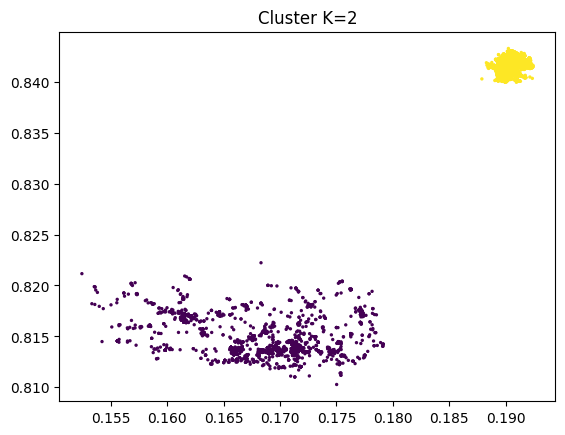

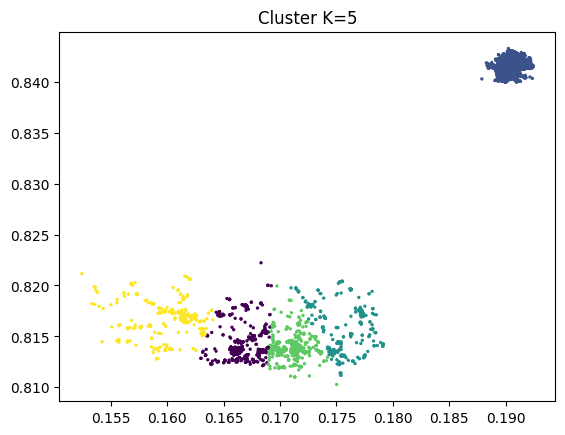

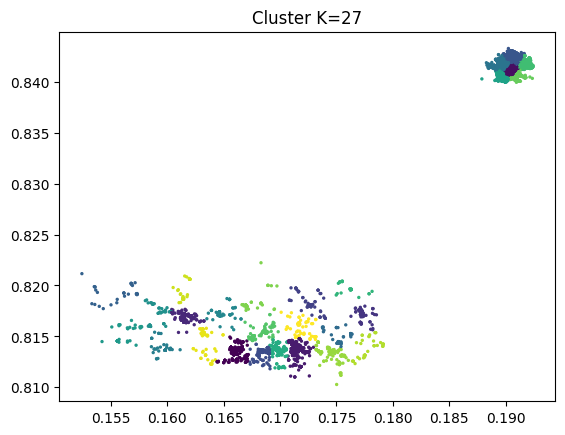

In [1]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

from mlModels.kmeans.locationClustering import findBestFittingK, projectCoords
from mlModels.kmeans.data.data import getClusterData
from utils.enums import Listings
from dotenv import load_dotenv
import os

os.chdir("/home/florian/Desktop/immopreis-regression")

load_dotenv("database/.env")

df = getClusterData()
coord_drop_mask = (df[Listings.LAT].isnull() | df[Listings.LON].isnull())
df = df[~coord_drop_mask]
df = df.drop(columns=[Listings.ID], errors='ignore')

k_candidates = findBestFittingK(df, seed=42, lower=2, upper=30)

coords_proj = projectCoords(df[[Listings.LAT, Listings.LON]].values)

for k in k_candidates:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(coords_proj)

    plt.figure()
    plt.scatter(coords_proj[:, 0], coords_proj[:, 1], c=labels, s=2)
    plt.title(f"Cluster K={k}")
    plt.show()


